# Demo in Bayesian Experiment Design - Linear Regression

In [ ]:
import arviz as az
import numpy as np
import plotly.express as px
import scipy.stats as sps
from numpy.typing import NDArray
from pymc import HalfCauchy, Model, Normal, sample

## Generate Toy Data

In [2]:
def generate_toy_data() -> tuple[NDArray, NDArray]:
    """Generate toy data.

    The data is generated from a simple linear regression model with
    the true intercept of 1 and slope of 2, with added Gaussian noise.

    Returns
    -------
    tuple[NDArray, NDArray]
        The generated toy data.

    """
    np.random.seed(42)

    size = 200
    true_intercept = 1
    true_slope = 2

    x = np.linspace(0, 1, size)
    # y = a + b*x
    true_regression_line = true_intercept + true_slope * x
    # add noise
    y = true_regression_line + np.random.normal(loc=0, scale=0.5, size=size)

    # Plot the generated data
    figure = px.scatter(x=x, y=y, title="Generated Data")
    figure.add_trace(
        px.line(
            x=x,
            y=true_regression_line,
            title="True Regression Line",
        ).data[0],
    )
    figure.show()

    return x, y

In [3]:
x, y = generate_toy_data()

## Fit a Linear Regression model

In [4]:
def fit_and_draw_samples(x: NDArray, y: NDArray) -> az.InferenceData:
    """Draw posterior samples from a Bayesian linear regression.

    Parameters
    ----------
    x, y : NDArray
        The toy data.

    Returns
    -------
    InferenceData
        The posterior samples.

    """
    with Model() as _model:
        sigma = HalfCauchy("sigma", beta=10)
        intercept = Normal("Intercept", 0, sigma=20)
        slope = Normal("slope", 0, sigma=20)

        _likelihood = Normal(
            "y", mu=intercept + slope * x, sigma=sigma, observed=y
        )

        idata = sample(
            draws=6000,
            tune=2000,
            chains=4,
            cores=4,
            random_seed=42,
            progressbar=True,
        )

        return idata

In [5]:
idata: az.InferenceData = fit_and_draw_samples(x, y)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, slope]


Output()

Sampling 4 chains for 2_000 tune and 6_000 draw iterations (8_000 + 24_000 draws total) took 2 seconds.


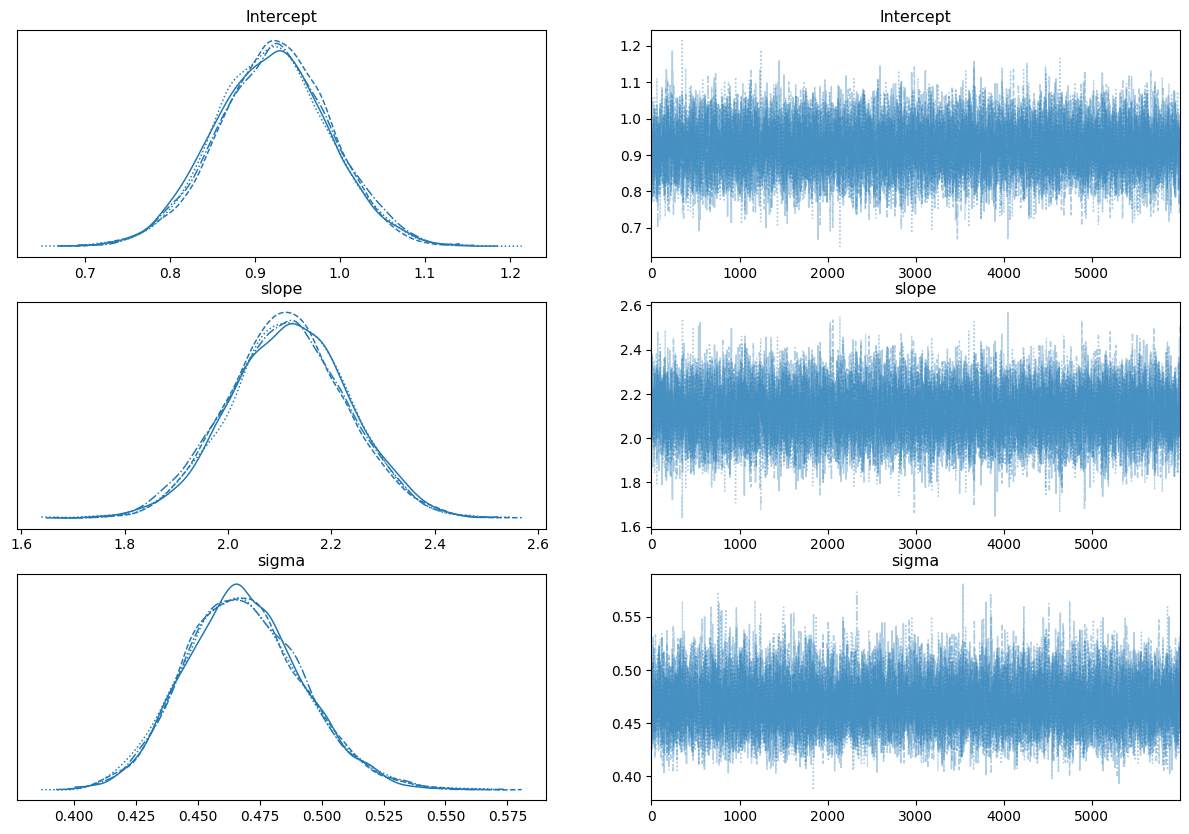

In [6]:
az.plot_trace(idata, figsize=(15, 10));

## Utility Function Definition

In this demo, we will use the expected information gain (EIG) as the utility function. This utility function is essentially the Kullback-Leibler divergence between the prior and posterior distributions. Let's also note that, in this case, the terms "prior" and "posterior" here are considered relative to the experiment (not relative to the model fitted above). Specifically, the "prior" distribution is actually the "posterior" distributions of the model fitted above while the "posterior" distribution is the distribution after the experiment has been carried out.

Mathematically, the expected information gain (EIG) is defined as a function of the experiment $d$ as follows:

$$
\begin{align*}
    EIG(d) & = E_{p(y, \theta | d)} \left[ \log \frac{p(\theta | y, d)}{p(\theta)}\right] \\
    & = E_{p(y, \theta | d)} \left[ \log \frac{p(\theta, y | d)}{p(\theta) \times p(y | d)}\right] \\
    & = E_{p(y, \theta | d)} \left[ \log \frac{p(y | \theta, d)}{p(y | d)}\right]
\end{align*}
$$

To calculate EIG involves a nested expectation over two variables: $\theta$ (the interested parameter) and $y$ (the response). A common way to estimate this is to use a nested Monte Carlo method (NMC):

$$
    E_{p(y, \theta | d)} \left[ \log \frac{p(y | \theta, d)}{p(y | d)}\right] \approx \frac{1}{N} \sum_{n=1}^N \log \frac{p(y_n | \theta_{n, 0}, d)}{\frac{1}{M} \sum_{m=1}^M p(y_n | \theta_{n, m}, d)}
$$

where:
- $\theta_{n, m} \sim p(\theta)$: for this, we will use right away the samples drawn when fitting the linear regression model above.
- $y_n \sim p(y | \theta_{n, 0}, d)$: for this, we need to draw more samples under the constraint of a given experiment.

Based on a research paper, the optimal choices of $M$ and $N$ are $M \approx \sqrt{N}$.

Now, let's specify the scope of our demo. Let's suppose that our experiments only involve changing the value of the variable $x$, and we are only interested in the slope variable.

In other words, the specifications of our demo are:
- $d$: the experiment changes the value of $x$ to take discrete values in either of the following: $[-1, -0.5, 0, 0.5, 1]$.
- $\theta$: the variable we're interested in is the slope.

We will use point estimates for other variables used in the calculation of the EIG.

In [ ]:
def expected_information_gain(
    x: float,
    slope_samples: NDArray[np.float64],
    intercept_est: float,
    sigma_est: float,
) -> float:
    """Estimate the expected information gain (EIG).

    Parameters
    ----------
    x : float
        The experiment design point.
    slope_samples : NDArray[np.float64] of shape (N, M)
        The posterior samples of the slope.
    intercept_est : float
        The point estimate of the intercept.
    sigma_est : float
        The point estimate of the noise.

    Returns
    -------
    float
        The estimated EIG at the design point.

    """
    np.random.seed(42)

    y_samples = np.random.normal(
        loc=slope_samples[:, 0] * x + intercept_est, scale=sigma_est
    )

    return np.log(
        sps.norm.pdf(
            x=y_samples,
            loc=slope_samples[:, 0] * x + intercept_est,
            scale=sigma_est,
        )
        / sps.norm.pdf(
            y_samples[:, np.newaxis],
            loc=slope_samples[:, 1:] * x + intercept_est,
            scale=sigma_est,
        ).mean(axis=1)
    ).mean()


In [9]:
slope_samples = idata.posterior["slope"].values.flatten().reshape(800, 30)
intercept_est = idata.posterior["Intercept"].values.mean()
sigma_est = idata.posterior["sigma"].values.mean()

experiments = [-1, -0.5, 0, 0.5, 1]
for x in experiments:
    eig = expected_information_gain(x, slope_samples, intercept_est, sigma_est)
    print(f"EIG at x={x}: {eig:.4f}")

EIG at x=-1: 0.0289
EIG at x=-0.5: 0.0074
EIG at x=0: 0.0000
EIG at x=0.5: 0.0071
EIG at x=1: 0.0282


Based on the results above, we can see that the experiment with $x = 1$ or $x=-1$ provides us with the most information about the distribution of the slope parameter while the choice $x = 0$ does not provide any information at all.

## Take-aways

In this demo, I've used a Monte Carlo method to estimate the utility function, and, since it involves nested expectations, the number of samples required is quite large. In this case, I've drawn 6000 posterior samples over 4 chains (24k samples in total). Still, it only provides 800 x 30 samples for a nested estimation.